# HSV Split-and-Merge Fruit Segmentation — Demo Notebook

**Computer Vision, Assignment 2 — Deggendorf Institute of Technology**

This notebook drives the `fruitseg` package stage by stage and visualises every
intermediate result (guard mask, Sobel edges, quadtree split, RAG merge, final
overlay) — ready material for the *technical-background* slides.

It **runs top-to-bottom without the dataset** using a synthetic scene
(`USE_SYNTHETIC = True`). To use the real data, set the flag to `False` and fill
in your Fruits-360 / Fruits-262 paths in the configuration cell.

**Algorithm origins (see README.md for full IEEE references):** split-and-merge —
Horowitz & Pavlidis (J. ACM 1976); HSV — Smith (SIGGRAPH '78); circular hue
statistics — Mardia & Jupp (2000); median filter — Tukey (1977); morphology —
Serra (1982); Sobel operator — Sobel & Feldman (SAIL 1968); edge-integrated
splitting — Pavlidis & Liow (IEEE TPAMI 1990).


## 0. Setup

In [3]:
pip install cv2-python
pip install numpy

SyntaxError: invalid syntax (1789221027.py, line 1)

In [ ]:
pip install cv2-python numpy

In [1]:
import os, sys, glob, tempfile
import numpy as np
import cv2
import matplotlib.pyplot as plt

# make the fruitseg package importable (this notebook lives next to it)
sys.path.insert(0, os.path.abspath('..'))  # project root (this notebook is in notebooks/)

from fruitseg import (build_references, segment_image, SegmentationConfig)
from fruitseg.color_space import to_hsv_float, guard_mask
from fruitseg.preprocessing import median_filter, gaussian_lowpass, sobel_edges
from fruitseg.features import region_features
from fruitseg.classify import classify_regions

def show(img_bgr, title='', ax=None, cmap=None):
    """Display a BGR image (or single-channel map) with matplotlib."""
    ax = ax or plt.gca()
    if img_bgr.ndim == 3:
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img_bgr, cmap=cmap or 'viridis')
    ax.set_title(title); ax.axis('off')

def colorize_labels(label_map, seed=0):
    """Map each region label to a random colour for visualisation."""
    rng = np.random.default_rng(seed)
    n = int(label_map.max()) + 1
    lut = rng.integers(40, 255, size=(n, 3), dtype=np.uint8)
    return lut[label_map]

print('fruitseg package loaded OK')


ModuleNotFoundError: No module named 'cv2'

## 1. Configuration

In [2]:
USE_SYNTHETIC = True   # set False to use the real Fruits-360 / Fruits-262 data

# --- real-data paths (used only when USE_SYNTHETIC = False) -------------------
TRAIN_DIR = '/path/to/Fruits-360/Training'
TEST_DIR  = '/path/to/Fruits-360/Test'
SCENE_IMG = '/path/to/fruits-262/some_multi_fruit_image.jpg'

# class spec: (Fruits-360 folder, display name, overlay colour BGR)
SPEC = [
    ('Strawberry', 'Strawberry', (0, 0, 255)),   # red
    ('Banana',     'Banana',     (0, 255, 255)), # yellow
    ('Avocado',    'Avocado',    (0, 200, 0)),   # green
]

EXTENDED = len(SPEC) >= 5         # 4-descriptor features for 5/10 fruits
cfg = SegmentationConfig(extended_features=EXTENDED, max_side=320)
cfg


SegmentationConfig(median_ksize=5, gaussian_sigma=1.5, s_min=0.15, v_min=0.15, tau_h=0.05, tau_s=0.02, tau_e=0.15, min_size=4, min_start_depth=2, hue_thresh=0.3, sat_thresh=0.15, merged_var_h=0.08, merged_var_s=0.03, edge_veto=0.35, extended_features=False, reject_z=1.8, min_valid=30, morph_radius=3, min_area=150, max_side=320)

## 2. Data

If `USE_SYNTHETIC`, we generate a tiny Train folder of solid-colour blobs on a
white background (mimicking Fruits-360) and one textured multi-fruit scene
(mimicking Fruits-262). Otherwise we point at the real folders.

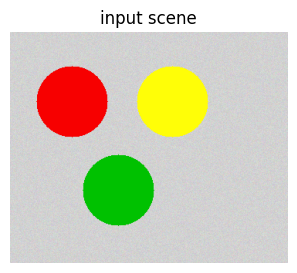

TRAIN_DIR = /tmp/tmp0ylzp3q4/Training


In [3]:
def _solid_fruit(color, size=100, r=38, jitter=10):
    img = np.full((size, size, 3), 255, np.uint8)
    c = np.clip(np.array(color) + np.random.randint(-jitter, jitter, 3), 0, 255)
    cv2.circle(img, (size//2, size//2), r, c.tolist(), -1)
    return img

def _multi_scene(spec):
    H, W = 300, 360
    scene = np.full((H, W, 3), 210, np.uint8)
    scene = np.clip(scene.astype(int) + np.random.randint(-12, 12, (H, W, 3)), 0, 255).astype(np.uint8)
    for (cy, cx), (_f, _n, color) in zip([(90,80),(90,210),(205,140)], spec):
        c = np.clip(np.array(color) + np.random.randint(-8, 8, 3), 0, 255)
        cv2.circle(scene, (cx, cy), 46, c.tolist(), -1)
    return scene

np.random.seed(0)
_tmp = None
if USE_SYNTHETIC:
    _tmp = tempfile.mkdtemp()
    for split, k in (('Training', 14), ('Test', 8)):
        for folder, _n, color in SPEC:
            d = os.path.join(_tmp, split, folder); os.makedirs(d, exist_ok=True)
            for i in range(k):
                cv2.imwrite(os.path.join(d, f'{i}.jpg'), _solid_fruit(color))
    TRAIN_DIR = os.path.join(_tmp, 'Training')
    TEST_DIR  = os.path.join(_tmp, 'Test')
    scene = _multi_scene(SPEC)
else:
    scene = cv2.imread(SCENE_IMG, cv2.IMREAD_COLOR)
    assert scene is not None, f'could not read {SCENE_IMG}'

plt.figure(figsize=(4,3)); show(scene, 'input scene'); plt.show()
print('TRAIN_DIR =', TRAIN_DIR)


## 3. Build class references (from Train only)

Each class reference is the mean feature vector over its Train images (fruit
isolated from the white background). The global z-score parameters are also
returned, used later by the classifier. **Tuning must use Train only.**

In [4]:
refs, nmean, nstd = build_references(TRAIN_DIR, SPEC, extended=EXTENDED)
for r in refs:
    print(f'{r.name:<12} n={r.n_images:<4} mean_feature={np.round(r.mean_feature, 3)}')
print('\nz-score mean:', np.round(nmean, 3))
print('z-score std :', np.round(nstd, 3))


Strawberry   n=14   mean_feature=[1.    0.005 0.001]
Banana       n=14   mean_feature=[0.493 0.869 0.023]
Avocado      n=14   mean_feature=[-0.5    0.866  0.008]

z-score mean: [0.331 0.58  0.011]
z-score std : [0.623 0.407 0.009]


## 4. Run the pipeline with debug output

`segment_image(..., return_debug=True)` returns the intermediate maps so we can
visualise each stage.

In [5]:
res = segment_image(scene, refs, nmean, nstd, cfg, return_debug=True)
print('split regions :', int(res['split_labels'].max()) + 1)
print('merged regions:', int(res['merged_labels'].max()) + 1)


split regions : 475
merged regions: 320


### 4a. Preprocessing and HSV channels

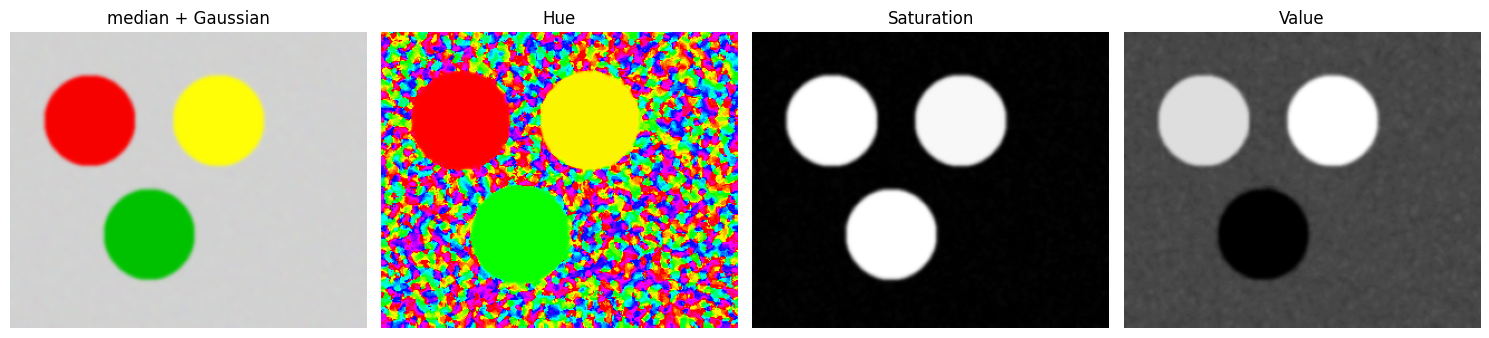

In [6]:
pre = res['preprocessed']
h, s, v = to_hsv_float(pre)
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(pre, 'median + Gaussian', ax[0])
ax[1].imshow(h, cmap='hsv'); ax[1].set_title('Hue'); ax[1].axis('off')
ax[2].imshow(s, cmap='gray'); ax[2].set_title('Saturation'); ax[2].axis('off')
ax[3].imshow(v, cmap='gray'); ax[3].set_title('Value'); ax[3].axis('off')
plt.tight_layout(); plt.show()


### 4b. Guard mask and Sobel edges

The guard mask is the foundation: hue is only trusted where the pixel is bright
and saturated (Smith 1978). The Sobel edge map (Sobel & Feldman 1968) drives the
edge-based split criterion.

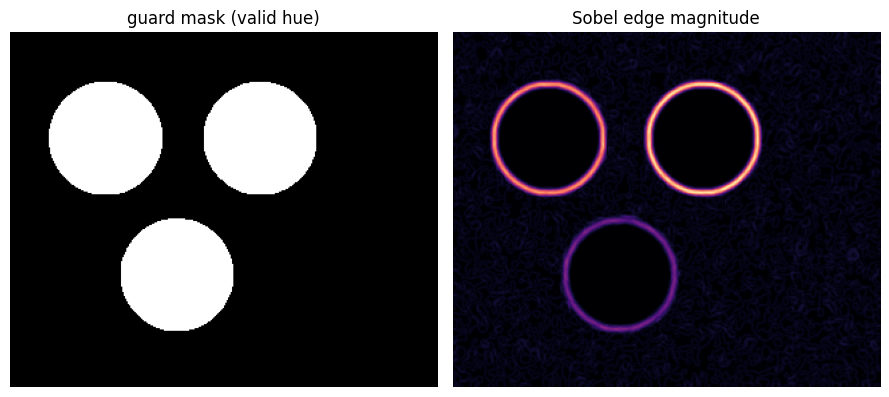

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(res['valid'], cmap='gray'); ax[0].set_title('guard mask (valid hue)'); ax[0].axis('off')
ax[1].imshow(res['edges'], cmap='magma'); ax[1].set_title('Sobel edge magnitude'); ax[1].axis('off')
plt.tight_layout(); plt.show()


### 4c. Split → Merge

The quadtree split starts from >=16 forced blocks and subdivides on hue/saturation
variance OR a Sobel edge (Horowitz & Pavlidis 1976; Pavlidis & Liow 1990). The
merge then collapses adjacent same-colour regions on the Region Adjacency Graph.

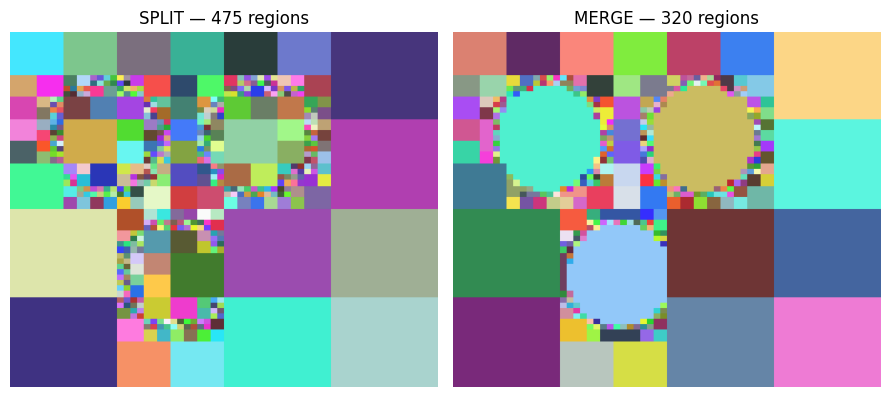

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
show(colorize_labels(res['split_labels'], 1), f"SPLIT — {int(res['split_labels'].max())+1} regions", ax[0])
show(colorize_labels(res['merged_labels'], 2), f"MERGE — {int(res['merged_labels'].max())+1} regions", ax[1])
plt.tight_layout(); plt.show()


### 4d. Final classification overlay

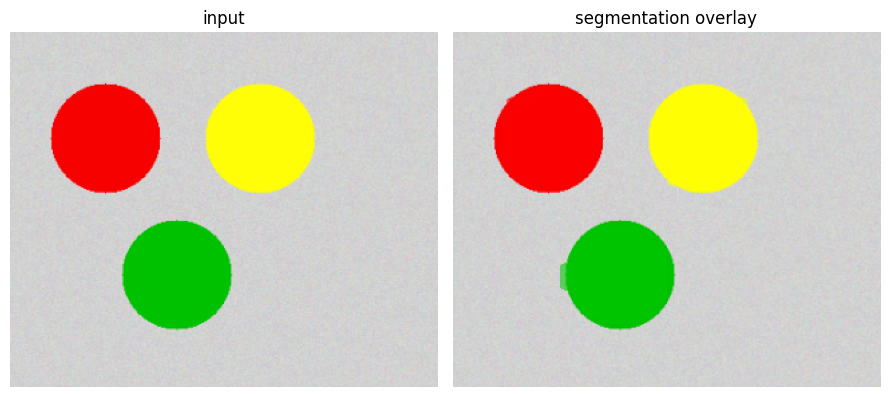

classes detected: ['Strawberry', 'Banana', 'Avocado']


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
show(scene if scene.shape[:2] == res['overlay'].shape[:2]
     else cv2.resize(scene, res['overlay'].shape[1::-1]), 'input', ax[0])
show(res['overlay'], 'segmentation overlay', ax[1])
plt.tight_layout(); plt.show()

present = sorted(set(res['class_map'][res['class_map'] >= 0].ravel().tolist()))
print('classes detected:', [refs[i].name for i in present])


## 5. Evaluation — confusion matrix + accuracy/recall/F1

Validation on single-fruit Test images. For the bonus, change `SPEC` to 5 or 10
fruits and re-run the notebook.

In [10]:
from fruitseg import evaluate_classification, print_report

result = evaluate_classification(TEST_DIR, SPEC, refs, nmean, nstd, cfg,
                                 max_per_class=8 if USE_SYNTHETIC else 60)
print_report(result)



Confusion matrix (rows = true, cols = predicted):
             Strawb  Banana  Avocad
Strawberry        8       0       0
Banana            0       8       0
Avocado           0       0       8

Overall accuracy: 1.000

class         prec  recall     f1     n
Strawberry   1.000   1.000  1.000     8
Banana       1.000   1.000  1.000     8
Avocado      1.000   1.000  1.000     8

Correct: 24   Wrong: 0


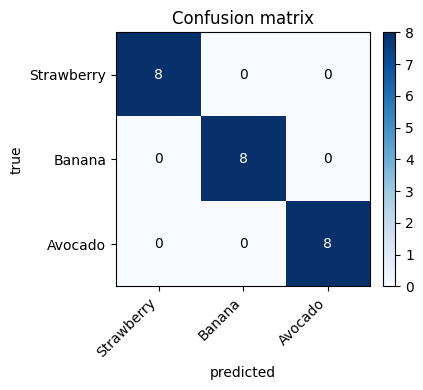

In [11]:
# confusion matrix as a heatmap
conf = result['confusion']; names = result['labels']
fig, axh = plt.subplots(figsize=(4.5, 4))
im = axh.imshow(conf, cmap='Blues')
axh.set_xticks(range(len(names))); axh.set_xticklabels(names, rotation=45, ha='right')
axh.set_yticks(range(len(names))); axh.set_yticklabels(names)
axh.set_xlabel('predicted'); axh.set_ylabel('true'); axh.set_title('Confusion matrix')
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        axh.text(j, i, int(conf[i, j]), ha='center', va='center',
                 color='white' if conf[i, j] > conf.max()/2 else 'black')
plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()


## 6. Using the real data and tuning

1. Set `USE_SYNTHETIC = False` and fill in `TRAIN_DIR`, `TEST_DIR`, `SCENE_IMG`.
2. Make sure the folder names in `SPEC` match your Fruits-360 copy exactly
   (e.g. `Apple Red 1`). Rank classes by hue separation; add the hue-overlapping
   fruits (mandarin/orange, strawberry/raspberry) last for the 5/10-fruit bonus.
3. Tune `SegmentationConfig` **on Train only**. Key knobs: `s_min`/`v_min`
   (guard), `tau_h`/`tau_s`/`tau_e` (split), `hue_thresh`/`sat_thresh`/`edge_veto`
   (merge), `reject_z`/`min_area` (classification/cleanup).
4. Save the stage figures above for the slides, and the confusion matrices for
   the results slide. Log correct/wrong filenames from `result['correct_files']`
   and `result['wrong_files']` as the assignment requires.

**Integrity:** be able to explain every `(oc)` step (especially the split/merge
and circular statistics). Keep the AI-usage declaration on your closing slide.

In [12]:
# Example: list a few wrongly-classified files for the results slide
for path, true_name, pred_name in result['wrong_files'][:10]:
    print(f'{os.path.basename(path):<20} true={true_name:<12} pred={pred_name}')
if not result['wrong_files']:
    print('(no misclassifications on this run)')


(no misclassifications on this run)
